#Intro

#Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import scipy
import sklearn
from sklearn.metrics.pairwise import cosine_similarity

#Data


## Data Downloading


In [ ]:
import os
import urllib.request

os.makedirs("hw2-dataset", exist_ok=True)
base_url = "https://storage.googleapis.com/rec-sys-fmi/hw2-dataset"
for file_name in ["shared_articles.csv", "users_interactions.csv"]:
    target_path = os.path.join("hw2-dataset", file_name)
    if os.path.exists(target_path):
        print(f"{file_name} already exists")
        continue
    source_url = f"{base_url}/{file_name}"
    print(f"Downloading {source_url}")
    urllib.request.urlretrieve(source_url, target_path)

print("Dataset is ready in hw2-dataset/")


In [4]:
!ls .

Content_based_Recommender_Example.ipynb  hw2-dataset


In [5]:
!head hw2-dataset/shared_articles.csv

timestamp,eventType,contentId,authorPersonId,authorSessionId,authorUserAgent,authorRegion,authorCountry,contentType,url,title,text,lang
1459192779,CONTENT REMOVED,-6451309518266745024,4340306774493623681,8940341205206233829,,,,HTML,http://www.nytimes.com/2016/03/28/business/dealbook/ethereum-a-virtual-currency-enables-transactions-that-rival-bitcoins.html,"Ethereum, a Virtual Currency, Enables Transactions That Rival Bitcoin's","All of this work is still very early. The first full public version of the Ethereum software was recently released, and the system could face some of the same technical and legal problems that have tarnished Bitcoin. Many Bitcoin advocates say Ethereum will face more security problems than Bitcoin because of the greater complexity of the software. Thus far, Ethereum has faced much less testing, and many fewer attacks, than Bitcoin. The novel design of Ethereum may also invite intense scrutiny by authorities given that potentially fraudulent contracts, like the 

##EDA

In [6]:
users_interactions_df = pd.read_csv("hw2-dataset/users_interactions.csv")
articles_df = pd.read_csv("hw2-dataset/shared_articles.csv")

###user interactions EDA and cleaning


In [7]:
users_interactions_df[0:200]

,timestamp,eventType,contentId,personId,sessionId,userAgent,userRegion,userCountry
0,1465413032,VIEW,-3499919498720038879,-8845298781299428018,1264196770339959068,NaN,NaN,NaN
1,1465412560,VIEW,8890720798209849691,-1032019229384696495,3621737643587579081,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,NY,US
2,1465416190,VIEW,310515487419366995,-1130272294246983140,2631864456530402479,NaN,NaN,NaN
3,1465413895,FOLLOW,310515487419366995,344280948527967603,-3167637573980064150,NaN,NaN,NaN
4,1465412290,VIEW,-7820640624231356730,-445337111692715325,5611481178424124714,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
195,1465843990,VIEW,-1046621686880462790,7584856762328012632,3546312890703794559,NaN,NaN,NaN
196,1465847008,VIEW,8657408509986329668,8239286975497580612,8163376774184337937,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,SP,BR
197,1465847809,VIEW,-4228415104574264137,-9016528795238256703,6922540700433450592,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_4...,MG,BR
198,1465845954,VIEW,-5148591903395022444,4313045637915476309,-3899113081891286607,NaN,NaN,NaN


In [8]:
#number of distinct users
len(users_interactions_df.personId.value_counts())


1895

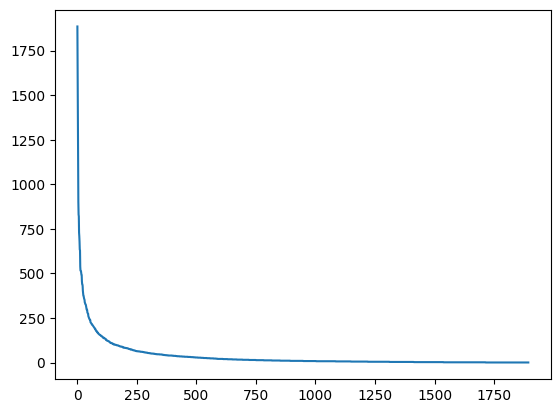

In [9]:
# interactions per user
plt.plot(range(0,len(users_interactions_df.personId.value_counts())),users_interactions_df.personId.value_counts())

In [10]:
users_interactions_df.eventType.value_counts()

eventType
VIEW               61086
LIKE                5745
BOOKMARK            2463
COMMENT CREATED     1611
FOLLOW              1407
Name: count, dtype: int64

In [11]:
users_interactions_df = users_interactions_df[["contentId","personId","eventType"]]
users_interactions_df[0:2]

,contentId,personId,eventType
0,-3499919498720038879,-8845298781299428018,VIEW
1,8890720798209849691,-1032019229384696495,VIEW


In [12]:
users_interactions_df.eventType.value_counts()

eventType
VIEW               61086
LIKE                5745
BOOKMARK            2463
COMMENT CREATED     1611
FOLLOW              1407
Name: count, dtype: int64

In [13]:
users_interactions_df.personId.value_counts()

personId
-1032019229384696495    1885
-1443636648652872475    1616
 3609194402293569455    1435
-2626634673110551643    1084
-3596626804281480007     903
                        ... 
 1052826425441302346       1
 1384537990076119578       1
-7902462005407456546       1
 7127895053297750118       1
 8113637998311268223       1
Name: count, Length: 1895, dtype: int64

In [43]:
users_interactions_df.contentId.value_counts()

contentId
-4029704725707465084    433
-133139342397538859     315
 8657408509986329668    294
-6783772548752091658    294
-6843047699859121724    281
                       ... 
 5191381587333696286      1
-4948717594596229869      1
-1868297195590431285      1
 7216750853471801538      1
-9040419159428373932      1
Name: count, Length: 2987, dtype: int64

In [14]:
users_interactions_df.shape

(72312, 3)

In [15]:
users_interactions_df.drop_duplicates(["contentId","personId"]).shape

(40710, 3)

In [40]:
#will leave only one record for user content, as in order to combine the diffent events will score them - view is implicit preference so 1 point,
# like/comment/bookmark/follow are explicit/implicit preferences that probably the user like it so 5 points. after that will aggragete with leaving the highest score, so if user viewed,liked and comment the score will still be 5(not higher)

di = {"VIEW":1, "LIKE":5,"BOOKMARK":5,"COMMENT CREATED":5,"FOLLOW":5}
users_interactions_df["prefScore"] = users_interactions_df["eventType"].map(di)


In [49]:
users_interactions_df.drop(columns=["eventType"], inplace=True, errors="ignore")
users_interactions_df = users_interactions_df.groupby(["contentId", "personId"], as_index=False).max()

In [18]:
users_interactions_df

,contentId,personId,eventType,prefScore
0,-3499919498720038879,-8845298781299428018,VIEW,1
1,8890720798209849691,-1032019229384696495,VIEW,1
2,310515487419366995,-1130272294246983140,VIEW,1
3,310515487419366995,344280948527967603,FOLLOW,5
4,-7820640624231356730,-445337111692715325,VIEW,1
...,...,...,...,...
72307,-6590819806697898649,-9016528795238256703,LIKE,5
72308,-5813211845057621660,102305705598210278,VIEW,1
72309,-1999468346928419252,-9196668942822132778,VIEW,1
72310,-6590819806697898649,-9016528795238256703,VIEW,1


In [50]:
#for the cold start problem
#lets drop all the users for which we don't have at least 5*6 scores (5 explicit prefenrences or correspondant number of implicit ones)
users_interactions_count_df = users_interactions_df.groupby('personId').sum()
users_with_enough_interactions_df = users_interactions_count_df[users_interactions_count_df["prefScore"] >= 30].reset_index()[["personId","prefScore"]]
users_with_enough_interactions_df

,personId,prefScore
0,-9223121837663643404,47
1,-9120685872592674274,76
2,-9109785559521267180,43
3,-9016528795238256703,518
4,-9009798162809551896,352
...,...,...
471,8940614478925413056,30
472,8968131284214320024,321
473,9109075639526981934,153
474,9148269800512008413,135


<Axes: >

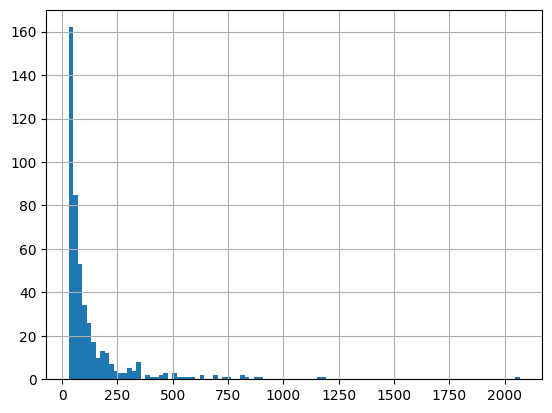

In [51]:
users_with_enough_interactions_df["prefScore"].hist(bins=100)

In [34]:
interactions_from_selected_users_df = users_interactions_df.merge(users_with_enough_interactions_df[["personId"]],
               how = 'right',
               left_on = 'personId',
               right_on = 'personId')
interactions_from_selected_users_df.shape

(63399, 4)

In [35]:
interactions_from_selected_users_df

,contentId,personId,eventType,prefScore
0,7516228655554309785,-9223121837663643404,VIEW,1
1,3041906492387035176,-9223121837663643404,VIEW,1
2,-3750879736572068916,-9223121837663643404,VIEW,1
3,-730957269757756529,-9223121837663643404,VIEW,1
4,-8949113594875411859,-9223121837663643404,VIEW,1
...,...,...,...,...
63394,-1572252285162838958,9210530975708218054,VIEW,1
63395,3660989387512978561,9210530975708218054,VIEW,1
63396,-1572252285162838958,9210530975708218054,VIEW,1
63397,-1572252285162838958,9210530975708218054,VIEW,1


###arcticles EDA and cleaning

In [36]:
articles_df[0:2]

,contentId,title,text
0,-6451309518266745024,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...
1,-4110354420726924665,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...


In [58]:
articles_df = pd.read_csv("hw2-dataset/shared_articles.csv")
articles_df["lang"].value_counts()

lang
en    2264
pt     850
la       4
es       2
ja       2
Name: count, dtype: int64

In [ ]:
articles_df["lang"].value_counts()


For our case of demonstrating content based filtering we are interested only in the PersonId-ContentId-Action information + the title and text of the Contents as we will left only english texts.

In [59]:
articles_df = articles_df[articles_df["lang"]=="en"]
articles_df = articles_df[["contentId","title","text"]]
articles_df[0:2]

,contentId,title,text
0,-6451309518266745024,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...
1,-4110354420726924665,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...


In [60]:
#leave only unique contentIds
articles_df = articles_df.drop_duplicates("contentId")
articles_df.shape

(2218, 3)

###Final Cleaning


In [61]:
print(interactions_from_selected_users_df.shape);
final_interactions = interactions_from_selected_users_df.merge(articles_df,
               how = 'right',
               left_on = 'contentId',
               right_on = 'contentId')
print(final_interactions.shape)

(63399, 4)
(42455, 6)


In [62]:
interactions_from_selected_users_df.personId.value_counts()

personId
-1032019229384696495    1885
-1443636648652872475    1616
 3609194402293569455    1435
-2626634673110551643    1084
-3596626804281480007     903
                        ... 
 6879394870211872116      14
-9207251133131336884      14
 1037187242736800310      13
 852862045361757752       11
-5629192146302945053      10
Name: count, Length: 606, dtype: int64

In [63]:
final_interactions_count_df = final_interactions.groupby('personId').sum().reset_index()[["personId","prefScore"]]
final_interactions_count_df = final_interactions_count_df[final_interactions_count_df["prefScore"]>=30]
final_users_with_enough_interactions_df = final_interactions_count_df[final_interactions_count_df["prefScore"]>=30]

print('# users after filtering:',final_users_with_enough_interactions_df.shape[0])
print('# interactions after filtering:',final_interactions_count_df.shape[0])

# users after filtering: 405
# interactions after filtering: 405


In [64]:
final_interactions = final_interactions.merge(final_users_with_enough_interactions_df[["personId"]],
               how = 'right',
               left_on = 'personId',
               right_on = 'personId')
print('# interactions after final filtering:',final_interactions.shape[0])

# interactions after final filtering: 39836


In [65]:
interactions_train_df, interactions_test_df = train_test_split(final_interactions,
                                   stratify=final_interactions['personId'],
                                   test_size=0.30,
                                   random_state=13)

print('# interactions on Train set: %d' % len(interactions_train_df))
print('# interactions on Test set: %d' % len(interactions_test_df))

# interactions on Train set: 27885
# interactions on Test set: 11951


#Content Based Recommender


In [24]:
# train set is at interactions_train_df
# test set is at interactions_test_df

In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopwords_list = stopwords.words('english')

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    # min_df=0.005,
    # max_df=0.5,
    max_features=1000,
    stop_words=stopwords_list,
)

item_ids = articles_df['contentId'].tolist()
documents = (articles_df['title'].fillna('') + " " + articles_df['text'].fillna('')).astype(str)
tfidf_matrix = vectorizer.fit_transform(documents)
tfidf_feature_names = vectorizer.get_feature_names_out()


In [68]:
print(tfidf_matrix.shape)
print(tfidf_feature_names)

(2218, 1000)
['000' '10' '100' '12' '15' '20' '2014' '2015' '2016' '30' '50' 'ability'
 'able' 'access' 'according' 'account' 'accounts' 'achieve' 'across'
 'action' 'active' 'activity' 'actual' 'actually' 'ad' 'add' 'added'
 'adding' 'addition' 'additional' 'address' 'advanced' 'advantage' 'agile'
 'ago' 'ai' 'algorithm' 'algorithms' 'allow' 'allowing' 'allows' 'almost'
 'along' 'already' 'also' 'although' 'always' 'amazon' 'among' 'amount'
 'analysis' 'analytics' 'android' 'announced' 'another' 'answer' 'anyone'
 'anything' 'api' 'apis' 'app' 'apple' 'application' 'applications'
 'apply' 'approach' 'apps' 'architecture' 'area' 'areas' 'around'
 'article' 'artificial' 'artificial intelligence' 'ask' 'asked'
 'attention' 'author' 'automated' 'automatically' 'available' 'average'
 'avoid' 'away' 'aws' 'back' 'background' 'bad' 'bank' 'banking' 'banks'
 'base' 'based' 'basic' 'become' 'becomes' 'behavior' 'behind' 'believe'
 'benefit' 'benefits' 'best' 'better' 'beyond' 'big' 'biggest' '

## Build User Profiles
The profiles are build from all the content which the user engaded with with taken the scores in consideration

In [69]:
# calculate user profiles from train dataset
user_profiles = {}
for person_id in interactions_train_df.personId.unique():
  user_profile = None
  interactions_person_df = interactions_train_df[interactions_train_df["personId"]==person_id]
  all_scores = interactions_person_df.prefScore.sum()
  for index, row in interactions_person_df.iterrows():
    content_id = row["contentId"]
    score = row["prefScore"]
    if(user_profile==None):
      user_profile = tfidf_matrix[item_ids.index(content_id)]*score/all_scores
    else:
      user_profile = scipy.sparse.vstack((user_profile,tfidf_matrix[item_ids.index(content_id)]*score/all_scores))
  user_profiles[person_id] = user_profile

### Evaluate

In [21]:
#recommend items to the users from the test dataset
#Evaluation is with MRR (https://en.wikipedia.org/wiki/Mean_reciprocal_rank)

In [70]:
mrr = 0
for person_id in interactions_train_df.personId.unique():
  cosine_similarities = cosine_similarity(user_profiles[person_id], tfidf_matrix)
  #print(cosine_similarities)
  similar_indices = cosine_similarities.argsort().flatten()[-1000:]
  items_to_ignore = interactions_train_df[interactions_train_df["personId"]==person_id]["contentId"].values
  items_to_evaluate = interactions_test_df[interactions_test_df["personId"]==person_id]["contentId"].values
  similar_indices_filtered = list(filter(lambda x: item_ids[x] not in items_to_ignore, similar_indices))
  print("after filtering train set items for person ", person_id, " = ",len(similar_indices_filtered))

  first_rank = len(similar_indices_filtered);
  l = len(similar_indices_filtered);
  for i in range(l):
    if(item_ids[similar_indices_filtered[l-i-1]] in items_to_evaluate):
      first_rank = i+1;
      break;
  mrr =mrr+ 1/first_rank
  print("first rank = ",first_rank);
  print("number of train items=",len(items_to_ignore))
mrr = mrr / interactions_train_df.personId.nunique()
print("mrr = ",mrr)

after filtering train set items for person  -1.5782875614100887e+18  =  933
first rank =  4
number of train items= 260
after filtering train set items for person  3.6091944022935695e+18  =  749
first rank =  2
number of train items= 668
after filtering train set items for person  3.3025560339629967e+18  =  885
first rank =  1
number of train items= 484
after filtering train set items for person  -1.602833675167377e+18  =  903
first rank =  6
number of train items= 228
after filtering train set items for person  8.018955947177723e+17  =  923
first rank =  17
number of train items= 166
after filtering train set items for person  4.2095174786603725e+18  =  956
first rank =  21
number of train items= 192
after filtering train set items for person  -2.979881261169775e+18  =  857
first rank =  3
number of train items= 363
after filtering train set items for person  1.9083391608575127e+18  =  970
first rank =  8
number of train items= 61
after filtering train set items for person  2.542290381

# My Content-Based Recommender (Improved)

This version improves the baseline by using:
- temporal holdout per user (latest interaction for testing),
- weighted user profiles from interaction strengths,
- robust text preprocessing and modern sklearn/pandas APIs,
- ranking metrics: Recall@5, Recall@10, and MRR@10.


In [71]:
import numpy as np
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity

EVENT_STRENGTH = {
    "VIEW": 1.0,
    "LIKE": 2.0,
    "BOOKMARK": 3.0,
    "FOLLOW": 4.0,
    "COMMENT CREATED": 5.0,
}
MIN_INTERACTIONS_PER_USER = 5


In [82]:
interactions_raw = pd.read_csv("hw2-dataset/users_interactions.csv")
articles_raw = pd.read_csv("hw2-dataset/shared_articles.csv")

articles_cb = articles_raw[(articles_raw["eventType"] == "CONTENT SHARED") & (articles_raw["lang"] == "en")].copy()
articles_cb = articles_cb[["contentId", "title", "text", "url"]].drop_duplicates("contentId")
articles_cb["title"] = articles_cb["title"].fillna("")
articles_cb["text"] = articles_cb["text"].fillna("")

interactions_cb = interactions_raw[["personId", "contentId", "eventType", "timestamp"]].copy()
interactions_cb = interactions_cb[interactions_cb["eventType"].isin(EVENT_STRENGTH)].copy()
interactions_cb["eventStrength"] = interactions_cb["eventType"].map(EVENT_STRENGTH)
interactions_cb = interactions_cb.merge(articles_cb[["contentId"]], on="contentId", how="inner")

interactions_cb = interactions_cb.sort_values("timestamp")
interactions_cb = interactions_cb.groupby(["personId", "contentId"], as_index=False).agg(
    eventStrength=("eventStrength", "max"),
    timestamp=("timestamp", "max"),
)

active_users = interactions_cb["personId"].value_counts()
active_users = active_users[active_users >= MIN_INTERACTIONS_PER_USER].index
interactions_cb = interactions_cb[interactions_cb["personId"].isin(active_users)].copy()

print("Interactions:", interactions_cb.shape)
print("Users:", interactions_cb["personId"].nunique())
print("Articles:", articles_cb.shape[0])


Interactions: (24458, 4)
Users: 785
Articles: 2211


In [83]:
interactions_cb = interactions_cb.sort_values(["personId", "timestamp"])
test_cb = interactions_cb.groupby("personId", as_index=False).tail(1).copy()
train_cb = interactions_cb.drop(test_cb.index).copy()

print("Train interactions:", train_cb.shape[0])
print("Test interactions:", test_cb.shape[0])
print("Train users:", train_cb["personId"].nunique())


Train interactions: 23673
Test interactions: 785
Train users: 785


In [84]:
cb_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    max_features=5000,
    stop_words=stopwords.words("english"),
)

articles_cb["document"] = (articles_cb["title"] + " " + articles_cb["text"]).str.strip()
item_tfidf = cb_vectorizer.fit_transform(articles_cb["document"])
feature_names = cb_vectorizer.get_feature_names_out()

content_id_to_idx = pd.Series(np.arange(len(articles_cb)), index=articles_cb["contentId"]).to_dict()

print("Item TF-IDF matrix:", item_tfidf.shape)
print("Feature count:", len(feature_names))


Item TF-IDF matrix: (2211, 5000)
Feature count: 5000


In [85]:
train_cb = train_cb.assign(item_idx=train_cb["contentId"].map(content_id_to_idx))
train_cb = train_cb.dropna(subset=["item_idx"]).copy()
train_cb["item_idx"] = train_cb["item_idx"].astype(int)

user_profiles = {}
seen_items = defaultdict(set)

for person_id, user_data in train_cb.groupby("personId"):
    item_indices = user_data["item_idx"].to_numpy()
    weights = user_data["eventStrength"].to_numpy(dtype=float)
    weighted_sum = item_tfidf[item_indices].multiply(weights[:, None]).sum(axis=0)
    if weights.sum() == 0:
        continue
    user_profiles[person_id] = np.asarray(weighted_sum) / weights.sum()
    seen_items[person_id] = set(user_data["contentId"].tolist())

print("User profiles built:", len(user_profiles))

def recommend_for_user(person_id, top_n=10):
    if person_id not in user_profiles:
        return pd.DataFrame(columns=["contentId", "score", "title", "url"])

    scores = cosine_similarity(user_profiles[person_id], item_tfidf).ravel()
    ranked_indices = np.argsort(scores)[::-1]

    rows = []
    for idx in ranked_indices:
        content_id = articles_cb.iloc[idx]["contentId"]
        if content_id in seen_items[person_id]:
            continue
        rows.append((content_id, float(scores[idx])))
        if len(rows) >= top_n:
            break

    recs = pd.DataFrame(rows, columns=["contentId", "score"])
    return recs.merge(articles_cb[["contentId", "title", "url"]], on="contentId", how="left")


User profiles built: 785


In [86]:
def evaluate_recommender(test_df, k=10):
    recall_at_5 = []
    recall_at_10 = []
    reciprocal_ranks = []

    for person_id, user_test in test_df.groupby("personId"):
        relevant_items = set(user_test["contentId"].tolist())
        recommendations = recommend_for_user(person_id, top_n=k)
        predicted_items = recommendations["contentId"].tolist()

        if not predicted_items:
            recall_at_5.append(0.0)
            recall_at_10.append(0.0)
            reciprocal_ranks.append(0.0)
            continue

        recall_at_5.append(len(set(predicted_items[:5]) & relevant_items) / len(relevant_items))
        recall_at_10.append(len(set(predicted_items[:10]) & relevant_items) / len(relevant_items))

        rr = 0.0
        for rank, content_id in enumerate(predicted_items[:k], start=1):
            if content_id in relevant_items:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    return {
        "Recall@5": float(np.mean(recall_at_5)),
        "Recall@10": float(np.mean(recall_at_10)),
        "MRR@10": float(np.mean(reciprocal_ranks)),
    }

metrics = evaluate_recommender(test_cb, k=10)
metrics


{'Recall@5': 0.016560509554140127,
 'Recall@10': 0.035668789808917196,
 'MRR@10': 0.011260742088767567}

In [77]:
sample_person_id = test_cb["personId"].iloc[0]
print("Sample user:", sample_person_id)
recommend_for_user(sample_person_id, top_n=10)


Sample user: -9223121837663643404


,contentId,score,title,url
0,8596997246990922861,0.507076,This year's Founders' Letter,https://googleblog.blogspot.com.br/2016/04/thi...
1,2858969450431709251,0.469000,Google I/O 2016: Android's failure to innovate...,http://appleinsider.com/articles/16/05/22/goog...
2,-4338308747999225618,0.432275,How the queen of Silicon Valley is helping Goo...,http://www.businessinsider.com/how-diane-green...
3,-5756697018315640725,0.415806,Being A Developer After 40 - Free Code Camp,https://medium.freecodecamp.com/being-a-develo...
4,-6308850935767965758,0.409523,So long MVP. Hello Minimum Loveable Product.,https://medium.com/the-happy-startup-school/be...
5,4785499183287168509,0.407198,The new tech talent you need to succeed in dig...,http://www.mckinsey.com/business-functions/dig...
6,1981046186743381313,0.399231,State of the Digital Nation 2016,http://blog.marvelapp.com/state-of-the-digital...
7,-4187268503708157132,0.399207,A Single App That'll Wrangle Your Millions of ...,http://www.wired.com/2016/04/franz-messenger-app/
8,-456574518348806233,0.399207,A Single App That'll Wrangle Your Millions of ...,http://www.wired.com/2016/04/franz-messenger-app/
9,-7002558676365724983,0.396497,Building a digital-banking business,http://www.mckinsey.com/industries/financial-s...
